<a href="https://colab.research.google.com/github/izia2081-0038-create/PlantVillage-Crop-Disease-Detection/blob/main/crop_disease_diagnosis_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PlantVillage crop disease detection


## 1. Setup, Configuration & Reproducibility

In [ ]:

%pip install -q kagglehub

In [ ]:
import os
import io
import json
import random
import warnings
import itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU") or "None (training will be slow)")

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
SEED = 42

QUICK_RUN     = False              # True -> ~250 imgs/class, 2 epochs. Use for a smoke test.
BACKBONE      = "resnet50"         # "resnet50" or "efficientnetb0"
RUN_ABLATION  = False              # §10. Adds ~10 min. Turn on for the final run.

IMG_SIZE      = (224, 224)         # standard input size for both backbones
BATCH_SIZE    = 32
TARGET_CROPS  = ("Corn_(maize)", "Potato", "Tomato")   # PlantVillage folder prefixes
SPLIT_RATIOS  = (0.70, 0.15, 0.15)                     # train / val / test

EPOCHS_CNN    = 20                 # baseline CNN from scratch
EPOCHS_HEAD   = 8                  # transfer learning, stage 1 (frozen backbone)
EPOCHS_FINE   = 10                 # transfer learning, stage 2 (fine-tuning)

if QUICK_RUN:
    EPOCHS_CNN, EPOCHS_HEAD, EPOCHS_FINE = 2, 2, 2

# --- Reproducibility -------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# --- Working directories (auto-detects Colab / Kaggle / local) --------
if Path("/kaggle/working").exists():
    WORK_DIR = Path("/kaggle/working")
elif Path("/content").exists():
    WORK_DIR = Path("/content")
else:
    WORK_DIR = Path.cwd() / "work"

MODEL_DIR   = WORK_DIR / "models"
RESULTS_DIR = WORK_DIR / "results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORK_DIR)
print("Models ->", MODEL_DIR)
print("Results ->", RESULTS_DIR)
print("Quick run   :", QUICK_RUN)
print("Backbone    :", BACKBONE)

Working dir : /content
Models -> /content/models
Results -> /content/results
Quick run   : False
Backbone    : resnet50


## 2. Dataset — Download & Locate

Source: [PlantVillage on Kaggle](https://www.kaggle.com/datasets/mohitsingh1804/plantvillage)
(Hughes & Salathé, 2015 — cite this in the report's Data section).

The archive is sometimes nested one or two folders deep and the exact layout varies by
upload, so instead of hard-coding a path we search for the directory whose immediate
children are the class folders. If you already have the data locally, set
`DATA_DIR` manually in the next cell and skip the download.

In [ ]:
DATA_DIR = None

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

if DATA_DIR is None:
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists() and any(kaggle_input.iterdir()):
        DATA_DIR = kaggle_input          # dataset added via the Kaggle UI
        print("Using Kaggle-mounted dataset at:", DATA_DIR)
    else:
        import kagglehub
        DATA_DIR = Path(kagglehub.dataset_download("mohitsingh1804/plantvillage"))
        print("Dataset downloaded to:", DATA_DIR)
else:
    DATA_DIR = Path(DATA_DIR)
    assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
    print("Using local dataset at:", DATA_DIR)

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset downloaded to: /kaggle/input/plantvillage


In [ ]:
def find_class_root(base, target_prefixes=TARGET_CROPS, max_depth=5):
    '''
    Return the directory whose immediate subfolders are the per-class image folders.

    Scoring: prefer the directory with the most subfolders matching our target crops;
    fall back to the directory with the most image-containing subfolders. This makes the
    notebook robust to the wrapper folders PlantVillage uploads often have
    (e.g. .../plantvillage/PlantVillage/Tomato___Late_blight/...).
    '''
    base = Path(base)
    best, best_score = None, (0, 0)

    for root, dirs, _ in os.walk(base):
        root = Path(root)
        if len(root.relative_to(base).parts) > max_depth:
            dirs[:] = []
            continue

        n_target, n_with_images = 0, 0
        for d in dirs:
            p = root / d
            try:
                has_img = any(f.suffix.lower() in IMG_EXTS
                              for f in itertools.islice(p.iterdir(), 25))
            except OSError:
                has_img = False
            if has_img:
                n_with_images += 1
                if d.startswith(target_prefixes):
                    n_target += 1

        score = (n_target, n_with_images)
        if score > best_score:
            best, best_score = root, score

    return best


CLASS_ROOT = find_class_root(DATA_DIR)
if CLASS_ROOT is None:
    raise FileNotFoundError(
        "Could not auto-detect the class-folder root. Inspect os.listdir(DATA_DIR) "
        "and set CLASS_ROOT manually to the folder that directly contains the "
        "'Tomato___...', 'Potato___...' subfolders."
    )

all_classes = sorted(d.name for d in CLASS_ROOT.iterdir() if d.is_dir())
print("Class root  :", CLASS_ROOT)
print(f"Found {len(all_classes)} class folders in total.")
print("Sample      :", all_classes[:3], "...")

Class root  : /kaggle/input/plantvillage/PlantVillage/val
Found 38 class folders in total.
Sample      : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust'] ...


In [ ]:

selected_classes = sorted(c for c in all_classes if c.startswith(TARGET_CROPS))
assert selected_classes, "No matching classes found — check CLASS_ROOT and folder names."

print(f"Keeping {len(selected_classes)} of {len(all_classes)} classes:\n")
for c in selected_classes:
    print("  -", c)

# --- Build one tidy DataFrame of every image -------------------------
records = []
for cls in selected_classes:
    for f in (CLASS_ROOT / cls).iterdir():
        if f.suffix.lower() in IMG_EXTS:
            records.append({"filepath": str(f), "label": cls})

df = pd.DataFrame(records)


def parse_label(label):
    # "Tomato___Early_blight" -> ("Tomato", "Early blight", False)
    crop, _, condition = label.partition("___")
    crop = crop.replace("_", " ").strip()
    condition = condition.replace("_", " ").strip() or "Unknown"
    return pd.Series([crop, condition, "healthy" in condition.lower()])


df[["crop", "condition", "is_healthy"]] = df["label"].apply(parse_label)

print(f"\nTotal images in scope : {len(df):,}")
print(f"Classes               : {df['label'].nunique()}")
print(f"Crops                 : {sorted(df['crop'].unique())}")
df.head()

Keeping 17 of 38 classes:

  - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  - Corn_(maize)___Common_rust_
  - Corn_(maize)___Northern_Leaf_Blight
  - Corn_(maize)___healthy
  - Potato___Early_blight
  - Potato___Late_blight
  - Potato___healthy
  - Tomato___Bacterial_spot
  - Tomato___Early_blight
  - Tomato___Late_blight
  - Tomato___Leaf_Mold
  - Tomato___Septoria_leaf_spot
  - Tomato___Spider_mites Two-spotted_spider_mite
  - Tomato___Target_Spot
  - Tomato___Tomato_Yellow_Leaf_Curl_Virus
  - Tomato___Tomato_mosaic_virus
  - Tomato___healthy

Total images in scope : 4,834
Classes               : 17
Crops                 : ['Corn (maize)', 'Potato', 'Tomato']


,filepath,label,crop,condition,is_healthy
0,/kaggle/input/plantvillage/PlantVillage/val/Co...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
1,/kaggle/input/plantvillage/PlantVillage/val/Co...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
2,/kaggle/input/plantvillage/PlantVillage/val/Co...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
3,/kaggle/input/plantvillage/PlantVillage/val/Co...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
4,/kaggle/input/plantvillage/PlantVillage/val/Co...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False


## 3. Exploratory Data Analysis

Five checks, each of which feeds a specific decision later in the pipeline:

| Check | Decision it informs |
|---|---|
| 3.1 Class distribution | whether class weighting is needed |
| 3.2 Healthy vs diseased | false-negative cost discussion in the ethics section |
| 3.3 Corrupted files | whether cleaning is needed before training |
| 3.4 Sample images | whether classes are visually separable at all |
| 3.5 Image dimensions | the resize target for the input pipeline |

The corruption check comes **third, not last**, on purpose: every cell after it reads
image files, so a single truncated JPEG left in the set would crash the cells below.

### 3.1 Class distribution & imbalance

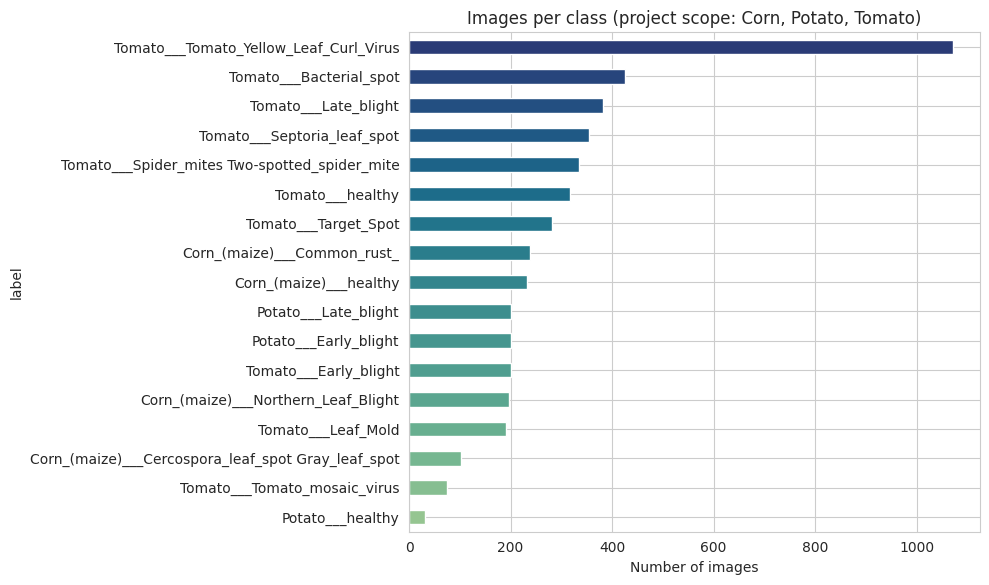

Smallest class : Potato___healthy -> 31
Largest class  : Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 1,071
Imbalance ratio: 34.5x

-> Imbalance is material, so class weights are applied during training (§5.3).


In [ ]:
class_counts = df["label"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(class_counts))))
class_counts.plot(kind="barh", ax=ax,
                  color=sns.color_palette("crest", len(class_counts)))
ax.set_xlabel("Number of images")
ax.set_title("Images per class (project scope: Corn, Potato, Tomato)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_class_distribution.png", dpi=150)
plt.show()

imbalance = class_counts.max() / class_counts.min()
print(f"Smallest class : {class_counts.idxmin()} -> {class_counts.min():,}")
print(f"Largest class  : {class_counts.idxmax()} -> {class_counts.max():,}")
print(f"Imbalance ratio: {imbalance:.1f}x")
print("\n-> Imbalance is material, so class weights are applied during training (§5.3)."
      if imbalance > 3 else "\n-> Imbalance is mild.")

### 3.2 Healthy vs diseased, per crop

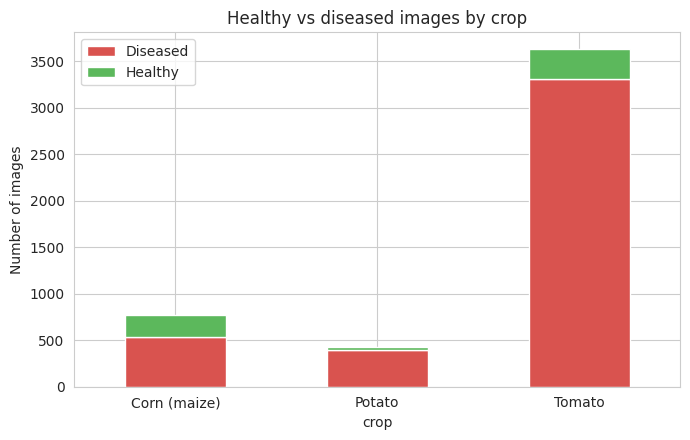

,Diseased,Healthy,% healthy
crop,,,
Corn (maize),539,233,30.2
Potato,400,31,7.2
Tomato,3313,318,8.8


In [ ]:
health = df.pivot_table(index="crop", columns="is_healthy", aggfunc="size", fill_value=0)
health.columns = ["Diseased", "Healthy"]

ax = health.plot(kind="bar", stacked=True, figsize=(7, 4.5),
                 color=["#d9534f", "#5cb85c"])
ax.set_ylabel("Number of images")
ax.set_title("Healthy vs diseased images by crop")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_healthy_vs_diseased.png", dpi=150)
plt.show()

health["% healthy"] = (100 * health["Healthy"] / health.sum(axis=1)).round(1)
health

### 3.3 Corrupted / unreadable files

Real image datasets contain truncated files. Catching them once here is far better than
having `fit()` die three epochs into a run.

In [ ]:
def find_corrupt(paths):
    bad = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            bad.append(p)
    return bad


corrupt = find_corrupt(df["filepath"])
print(f"Checked {len(df):,} images -> {len(corrupt)} unreadable.")

if corrupt:
    df = df[~df["filepath"].isin(corrupt)].reset_index(drop=True)
    print(f"Dropped them. {len(df):,} images remain.")

Checked 4,834 images -> 0 unreadable.


### 3.4 Sample images per class

Visual inspection matters here: several tomato diseases (Early blight vs Septoria leaf
spot vs Target spot) present as similar dark lesions, which is exactly where we expect
the confusion matrix in §9 to light up.

In [ ]:
def show_sample_grid(dataframe, n_classes=5, n_per_class=4, seed=SEED):
    rng = random.Random(seed)
    labels = rng.sample(sorted(dataframe["label"].unique()),
                        min(n_classes, dataframe["label"].nunique()))

    fig, axes = plt.subplots(len(labels), n_per_class,
                             figsize=(n_per_class * 2.4, len(labels) * 2.5))
    axes = np.atleast_2d(axes)

    for r, label in enumerate(labels):
        paths = (dataframe[dataframe["label"] == label]["filepath"]
                 .sample(n=n_per_class, random_state=seed).tolist())
        for c, p in enumerate(paths):
            axes[r, c].imshow(Image.open(p))
            axes[r, c].axis("off")
        axes[r, 0].set_title(label, fontsize=8, loc="left")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_sample_images.png", dpi=130)
    plt.show()


show_sample_grid(df)

### 3.5 Image dimensions & aspect ratio

In [ ]:
sample_paths = df["filepath"].sample(n=min(400, len(df)), random_state=SEED)
dims = []
for p in sample_paths:
    try:
        with Image.open(p) as im:
            dims.append(im.size)
    except Exception:
        continue          # belt-and-braces: §3.3 should already have removed these

dims_df = pd.DataFrame(dims, columns=["width", "height"])
print(dims_df.describe().loc[["min", "mean", "max"]].round(1))
print("\nMost common resolutions:")
print(dims_df.groupby(["width", "height"]).size().sort_values(ascending=False).head(3))
print(f"\n-> Resizing everything to {IMG_SIZE}, which both ResNet50 and "
      "EfficientNetB0 expect.")

      width  height
min   256.0   256.0
mean  256.0   256.0
max   256.0   256.0

Most common resolutions:
width  height
256    256       400
dtype: int64

-> Resizing everything to (224, 224), which both ResNet50 and EfficientNetB0 expect.


## 4. Stratified Train / Validation / Test Split

Split at the **file-path level** rather than physically copying 20,000 images into
`train/`, `val/`, `test/` folders. It is faster, uses no extra disk, and — more
importantly — makes the split reproducible from a single seed and keeps the exact
class-index order under our control (that order has to match the demo app later).

Stratification keeps the class proportions identical across all three splits, which
matters given the imbalance found in §3.1.

In [ ]:
if QUICK_RUN:
    parts = [g.sample(n=min(250, len(g)), random_state=SEED)
             for _, g in df.groupby("label")]
    df = pd.concat(parts).reset_index(drop=True)
    print(f"QUICK_RUN: subsampled to {len(df):,} images.")

CLASS_NAMES = sorted(df["label"].unique())
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df["y"] = df["label"].map(class_to_idx)

train_frac, val_frac, test_frac = SPLIT_RATIOS

train_df, temp_df = train_test_split(
    df, train_size=train_frac, stratify=df["y"], random_state=SEED, shuffle=True,
)
val_df, test_df = train_test_split(
    temp_df, train_size=val_frac / (val_frac + test_frac),
    stratify=temp_df["y"], random_state=SEED, shuffle=True,
)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(part):>6,} images  ({len(part)/len(df):.0%})")

print(f"\n{NUM_CLASSES} classes, index order:")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {i:2d}  {c}")

train:  3,383 images  (70%)
val  :    725 images  (15%)
test :    726 images  (15%)

17 classes, index order:
   0  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1  Corn_(maize)___Common_rust_
   2  Corn_(maize)___Northern_Leaf_Blight
   3  Corn_(maize)___healthy
   4  Potato___Early_blight
   5  Potato___Late_blight
   6  Potato___healthy
   7  Tomato___Bacterial_spot
   8  Tomato___Early_blight
   9  Tomato___Late_blight
  10  Tomato___Leaf_Mold
  11  Tomato___Septoria_leaf_spot
  12  Tomato___Spider_mites Two-spotted_spider_mite
  13  Tomato___Target_Spot
  14  Tomato___Tomato_Yellow_Leaf_Curl_Virus
  15  Tomato___Tomato_mosaic_virus
  16  Tomato___healthy


## 5. Input Pipeline & Augmentation

### Design decision: preprocessing lives *inside* the model

The `tf.data` pipeline outputs raw float pixels in `[0, 255]`. Rescaling and
backbone-specific normalisation are implemented as the **first layers of each model**
rather than in the pipeline.

Why this matters: the baseline CNN wants `[0, 1]` while ResNet50's `preprocess_input`
wants `[0, 255]` in BGR with ImageNet means subtracted. Doing this in the pipeline would
force two separate datasets and is the classic source of the "great validation accuracy,
garbage predictions in the app" bug. Baking it into the model means the saved
`.keras` file is fully self-contained — the demo app just feeds it a resized
`[0, 255]` image and needs no knowledge of which backbone was used.

In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)          # stays in [0, 255]
    img.set_shape((*IMG_SIZE, 3))
    return img, label


def make_dataset(frame, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame["filepath"].values, frame["y"].values.astype("int32"))
    )
    if shuffle:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)          # order preserved -> safe for confusion matrix

images, labels = next(iter(train_ds))
print("Batch shape :", images.shape)
print("Pixel range :", float(tf.reduce_min(images)), "->", float(tf.reduce_max(images)))
print("Label dtype :", labels.dtype, "| example labels:", labels[:8].numpy())

Batch shape : (32, 224, 224, 3)
Pixel range : 0.0 -> 255.0
Label dtype : <dtype: 'int32'> | example labels: [13  4  9 13 14 16  1  9]


### 5.2 Data augmentation

Augmentation is applied as Keras layers, which are **active during training only** and
automatically bypassed at inference. Transforms were chosen to mimic how a farmer would
actually photograph a leaf on a phone: arbitrary rotation and framing, mirror-image
orientation, variable distance, variable sunlight.

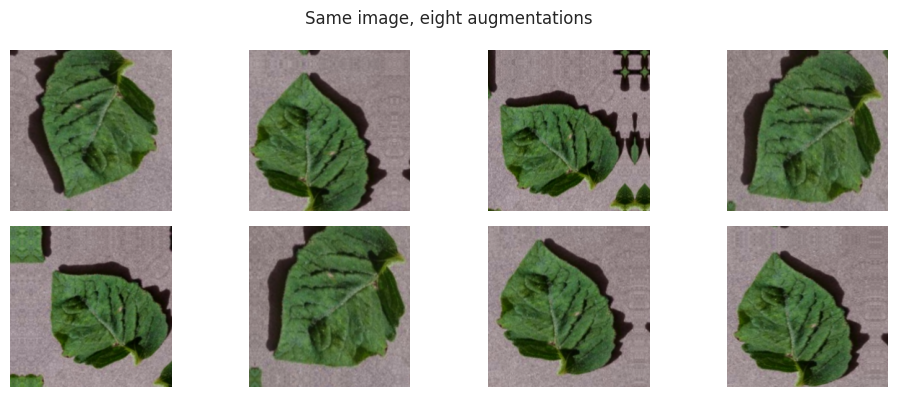

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    layers.RandomRotation(0.15, seed=SEED),      # +/- 54 degrees
    layers.RandomZoom(0.15, seed=SEED),
    layers.RandomTranslation(0.10, 0.10, seed=SEED),
    layers.RandomContrast(0.15, seed=SEED),
], name="data_augmentation")

# Sanity-check what the model actually sees
plt.figure(figsize=(10, 4))
sample = images[:1]
for i in range(8):
    aug = data_augmentation(sample, training=True)
    plt.subplot(2, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(aug[0], 0, 255), tf.uint8).numpy())
    plt.axis("off")
plt.suptitle("Same image, eight augmentations")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_preview.png", dpi=130)
plt.show()

### 5.3 Class weights

From §3.1 the dataset is imbalanced. Without correction the model can score well on
accuracy while quietly ignoring the smallest classes — and in this application the
smallest classes include the ones a farmer most needs flagged. Class weights raise the
loss contribution of rare classes so they are not drowned out.

In [ ]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["y"].values,
)
class_weight = {i: float(w) for i, w in enumerate(weights)}

pd.DataFrame({
    "class": CLASS_NAMES,
    "train_images": [int((train_df["y"] == i).sum()) for i in range(NUM_CLASSES)],
    "weight": [round(class_weight[i], 3) for i in range(NUM_CLASSES)],
}).sort_values("train_images")

,class,train_images,weight
6,Potato___healthy,22,9.045
15,Tomato___Tomato_mosaic_virus,52,3.827
0,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,72,2.764
10,Tomato___Leaf_Mold,134,1.485
2,Corn_(maize)___Northern_Leaf_Blight,138,1.442
8,Tomato___Early_blight,140,1.421
5,Potato___Late_blight,140,1.421
4,Potato___Early_blight,140,1.421
3,Corn_(maize)___healthy,163,1.221
1,Corn_(maize)___Common_rust_,167,1.192


## 6. Model 1 — Baseline CNN Trained From Scratch

The comparison baseline. Four Conv-BN-ReLU-Pool blocks with widening filters
(32 → 64 → 128 → 256), global average pooling instead of a large flatten-and-dense head
(far fewer parameters, less overfitting), then a dropout-regularised classifier.

**Regularisation used here:** batch normalisation, L2 weight decay, dropout, data
augmentation, early stopping and learning-rate scheduling — comfortably above the two
techniques the brief requires, and §10 measures what two of them are actually worth.

In [ ]:
def build_baseline_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    reg = tf.keras.regularizers.l2(1e-4)
    inputs = tf.keras.Input(shape=(*img_size, 3), name="image")

    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255, name="rescale")(x)     # [0,255] -> [0,1]

    for filters in (32, 64, 128, 256):
        x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return tf.keras.Model(inputs, outputs, name="baseline_cnn")


cnn_model = build_baseline_cnn()
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 425,425 (1.62 MB)

 Trainable params: 424,465 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
def make_callbacks(name, patience=6):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(MODEL_DIR / f"best_{name}.keras"),
            monitor="val_accuracy", save_best_only=True, verbose=0),
        tf.keras.callbacks.CSVLogger(str(RESULTS_DIR / f"{name}_training_log.csv")),
    ]


cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    class_weight=class_weight,
    callbacks=make_callbacks("baseline_cnn"),
    verbose=1,
)

Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - accuracy: 0.4307 - loss: 1.9415 - val_accuracy: 0.0883 - val_loss: 4.0086 - learning_rate: 0.0010
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.5661 - loss: 1.3671 - val_accuracy: 0.0883 - val_loss: 4.6507 - learning_rate: 0.0010
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.6305 - loss: 1.1666 - val_accuracy: 0.0966 - val_loss: 4.5853 - learning_rate: 0.0010
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - accuracy: 0.6722 - loss: 1.0426 - val_accuracy: 0.2786 - val_loss: 2.7079 - learning_rate: 0.0010
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.6701 - loss: 1.0124 - val_accuracy: 0.2662 - val_loss: 3.5096 - learning_rate: 0.0010
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.7044 - loss: 0.9089 - val_accuracy: 0.4910 - val_loss: 2.1010 - learning_rate: 0.0010
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.7

## 7. Model 2 — Transfer Learning (ResNet50 / EfficientNetB0)

The brief strongly encourages transfer learning for image tasks, and the justification is
concrete rather than fashionable: ~14,000 training images is far too few to learn general
edge, texture and colour-blob detectors from scratch, but those features are exactly what
an ImageNet-pretrained backbone already has. We only need to learn the last, task-specific
mapping from "leaf texture" to "disease".

**Two-stage protocol** (this is the part that is usually done wrong):

1. **Stage 1 — frozen backbone.** Train only the new classification head at a normal
   learning rate (1e-3). The head starts randomly initialised; letting large random
   gradients flow into pretrained weights would destroy them.
2. **Stage 2 — fine-tuning.** Unfreeze the top ~30 layers and continue at a much lower
   learning rate (1e-5) so pretrained features adapt to leaf imagery instead of being
   overwritten.

**BatchNorm layers stay frozen during fine-tuning.** They keep running statistics from
ImageNet; updating them on small batches is a well-known cause of a model that trains
beautifully and then collapses at inference.

In [ ]:
BACKBONES = {
    "resnet50": (
        tf.keras.applications.ResNet50,
        tf.keras.applications.resnet50.preprocess_input,
    ),
    "efficientnetb0": (
        tf.keras.applications.EfficientNetB0,
        tf.keras.applications.efficientnet.preprocess_input,
    ),
}
assert BACKBONE in BACKBONES, f"BACKBONE must be one of {list(BACKBONES)}"
BackboneFn, preprocess_input = BACKBONES[BACKBONE]


def build_transfer_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE, dropout=0.3):
    base = BackboneFn(include_top=False, weights="imagenet",
                      input_shape=(*img_size, 3))
    base.trainable = False                      # stage 1: frozen

    inputs = tf.keras.Input(shape=(*img_size, 3), name="image")
    x = data_augmentation(inputs)
    x = preprocess_input(x)                     # backbone-specific normalisation
    x = base(x, training=False)                 # keep BN in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = tf.keras.Model(inputs, outputs, name=f"transfer_{BACKBONE}")
    return model, base


transfer_model, base_model = build_transfer_model()
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable = np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights])
total = transfer_model.count_params()
print(f"Backbone            : {BACKBONE}")
print(f"Total parameters    : {total:,}")
print(f"Trainable (stage 1) : {int(trainable):,}  ({100*trainable/total:.2f}%)")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone            : resnet50
Total parameters    : 23,622,545
Trainable (stage 1) : 34,833  (0.15%)


### 7.1 Stage 1 — train the classification head (backbone frozen)

In [ ]:
head_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight,
    callbacks=make_callbacks("transfer_head", patience=4),
    verbose=1,
)

Epoch 1/8
106/106 ━━━━━━━━━━━━━━━━━━━━ 31s 209ms/step - accuracy: 0.5433 - loss: 1.5100 - val_accuracy: 0.7559 - val_loss: 0.7673 - learning_rate: 0.0010
Epoch 2/8
106/106 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.7925 - loss: 0.7115 - val_accuracy: 0.7614 - val_loss: 0.7178 - learning_rate: 0.0010
Epoch 3/8
106/106 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.8232 - loss: 0.5579 - val_accuracy: 0.7655 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 4/8
106/106 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.8625 - loss: 0.4534 - val_accuracy: 0.7986 - val_loss: 0.5846 - learning_rate: 0.0010
Epoch 5/8
106/106 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - accuracy: 0.8611 - loss: 0.4106 - val_accuracy: 0.8276 - val_loss: 0.5289 - learning_rate: 0.0010
Epoch 6/8
106/106 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.8883 - loss: 0.3797 - val_accuracy: 0.8566 - val_loss: 0.4326 - learning_rate: 0.0010
Epoch 7/8
106/106 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.8871 - l

### 7.2 Stage 2 — fine-tune the top of the backbone

In [ ]:
FINE_TUNE_LAYERS = 30

base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in base_model.layers:                      # never un-freeze BatchNorm
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile is mandatory after changing trainable flags.
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),        # 100x lower LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable = np.sum([np.prod(v.shape) for v in transfer_model.trainable_weights])
print(f"Trainable (stage 2) : {int(trainable):,} "
      f"({100*trainable/transfer_model.count_params():.2f}%)")

fine_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight,
    callbacks=make_callbacks("transfer_finetune", patience=4),
    verbose=1,
)

Trainable (stage 2) : 14,463,505 (61.23%)
Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 35s 236ms/step - accuracy: 0.8977 - loss: 0.3160 - val_accuracy: 0.8703 - val_loss: 0.4083 - learning_rate: 1.0000e-05
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.9228 - loss: 0.2401 - val_accuracy: 0.8855 - val_loss: 0.3900 - learning_rate: 1.0000e-05
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 209ms/step - accuracy: 0.9267 - loss: 0.2215 - val_accuracy: 0.8938 - val_loss: 0.3256 - learning_rate: 1.0000e-05
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.9406 - loss: 0.1756 - val_accuracy: 0.8772 - val_loss: 0.3873 - learning_rate: 1.0000e-05
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.9447 - loss: 0.1590 - val_accuracy: 0.8759 - val_loss: 0.3691 - learning_rate: 1.0000e-05
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 24s 228ms/step - accuracy: 0.9492 - loss: 0.1534 - val_accuracy: 0.9048 - val_loss: 0.3151 - learning_rate: 1.0000e-05
Epoc

## 8. Training Curves

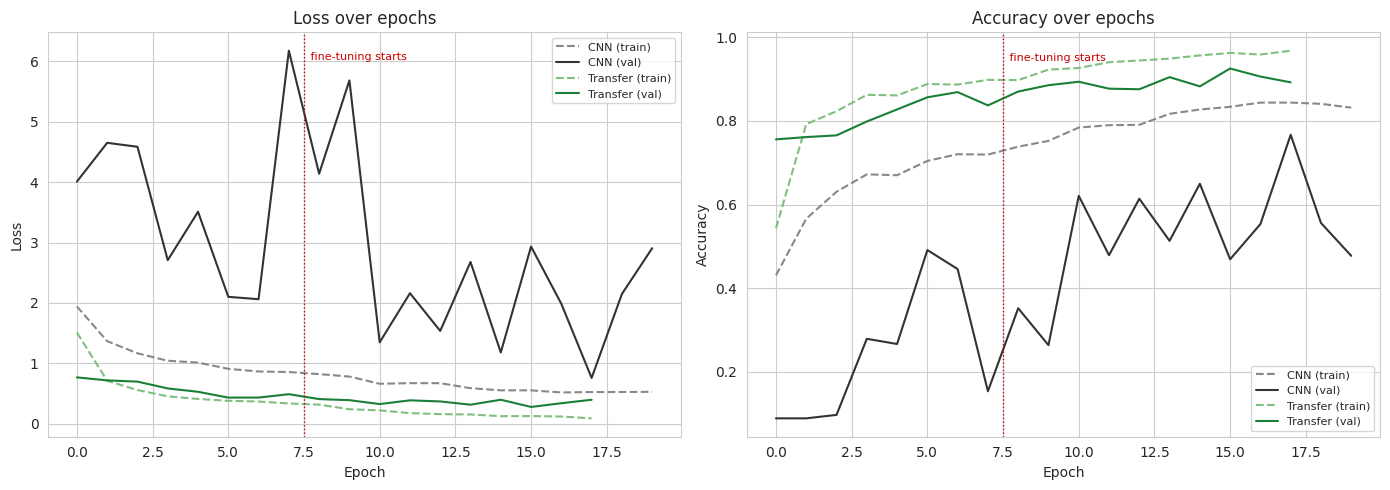

In [ ]:
def merge_histories(*histories):
    out = {}
    for h in histories:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out


cnn_hist = merge_histories(cnn_history)
tl_hist  = merge_histories(head_history, fine_history)
handoff  = len(head_history.history["loss"])     # where stage 1 ended

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [(axes[0], "loss", "Loss"), (axes[1], "accuracy", "Accuracy")]:
    ax.plot(cnn_hist[metric], "--", color="#888", label="CNN (train)")
    ax.plot(cnn_hist["val_" + metric], color="#333", label="CNN (val)")
    ax.plot(tl_hist[metric], "--", color="#7fbf7f", label="Transfer (train)")
    ax.plot(tl_hist["val_" + metric], color="#1a7f37", label="Transfer (val)")
    ax.axvline(handoff - 0.5, color="#c00", ls=":", lw=1)
    ax.text(handoff - 0.4, ax.get_ylim()[1] * 0.95, " fine-tuning starts",
            color="#c00", fontsize=8, va="top")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.set_title(f"{title} over epochs")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()

pd.DataFrame(cnn_hist).to_csv(RESULTS_DIR / "history_baseline_cnn.csv", index=False)
pd.DataFrame(tl_hist).to_csv(RESULTS_DIR / "history_transfer.csv", index=False)

**What to look for when writing this up:** the gap between the dashed (train) and solid
(val) lines is the overfitting signal, and the step at the red line shows what unfreezing
the backbone actually bought. If the transfer model's validation accuracy is already flat
before fine-tuning starts, say so — a finding that a technique did *not* help is a
legitimate and honest result.

## 9. Evaluation

Accuracy on its own is a poor headline metric for an imbalanced problem, so we report
macro-averaged precision, recall and F1 as well. Macro-averaging weights every class
equally regardless of size — which is the right choice here, because a rare disease
matters just as much to the farmer who has it as a common one.

### 9.1 Model comparison

In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])


def evaluate(model, name):
    probs = model.predict(test_ds, verbose=0)
    y_pred = probs.argmax(axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",
                                                  zero_division=0)
    _, _, f1w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted",
                                                   zero_division=0)
    return {
        "model": name,
        "params": f"{model.count_params():,}",
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "weighted_f1": f1w,
    }, y_pred, probs


cnn_metrics, cnn_pred, cnn_probs = evaluate(cnn_model, "Baseline CNN (from scratch)")
tl_metrics,  tl_pred,  tl_probs  = evaluate(transfer_model, f"Transfer learning ({BACKBONE})")

comparison = pd.DataFrame([cnn_metrics, tl_metrics])
comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
comparison.round(4)

In [ ]:
ax = comparison.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]].plot(
    kind="bar", figsize=(8, 4.5), rot=0, ylim=(0, 1.05),
    color=["#1a7f37", "#4c9be8", "#f0ad4e"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
ax.set_ylabel("Score")
ax.set_title("Test-set performance: from-scratch CNN vs transfer learning")
ax.set_xticklabels([t.get_text().replace(" (", "\n(") for t in ax.get_xticklabels()])
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=150)
plt.show()

delta = tl_metrics["macro_f1"] - cnn_metrics["macro_f1"]
print(f"Transfer learning changes macro-F1 by {delta:+.4f} "
      f"({delta*100:+.2f} percentage points) versus the from-scratch CNN.")

### 9.2 Per-class breakdown (best model)

In [ ]:
best_model, best_pred, best_probs, best_name = (
    (transfer_model, tl_pred, tl_probs, f"Transfer learning ({BACKBONE})")
    if tl_metrics["macro_f1"] >= cnn_metrics["macro_f1"]
    else (cnn_model, cnn_pred, cnn_probs, "Baseline CNN")
)
print("Best model by macro-F1:", best_name, "\n")

report = classification_report(y_true, best_pred, target_names=CLASS_NAMES,
                               digits=3, zero_division=0)
print(report)

report_df = pd.DataFrame(
    classification_report(y_true, best_pred, target_names=CLASS_NAMES,
                          output_dict=True, zero_division=0)
).T
report_df.to_csv(RESULTS_DIR / "classification_report.csv")

### 9.3 Confusion matrix

In [ ]:
cm = confusion_matrix(y_true, best_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

short = [c.replace("Corn_(maize)___", "Corn: ")
          .replace("Potato___", "Potato: ")
          .replace("Tomato___", "Tomato: ")
          .replace("_", " ")[:32] for c in CLASS_NAMES]

plt.figure(figsize=(11, 9))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Greens", cbar_kws={"label": "Row-normalised"},
            xticklabels=short, yticklabels=short, annot_kws={"size": 7}, vmin=0, vmax=1)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix — {best_name}\n(colour = recall per row, number = image count)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

### 9.4 Error analysis — where the errors concentrate

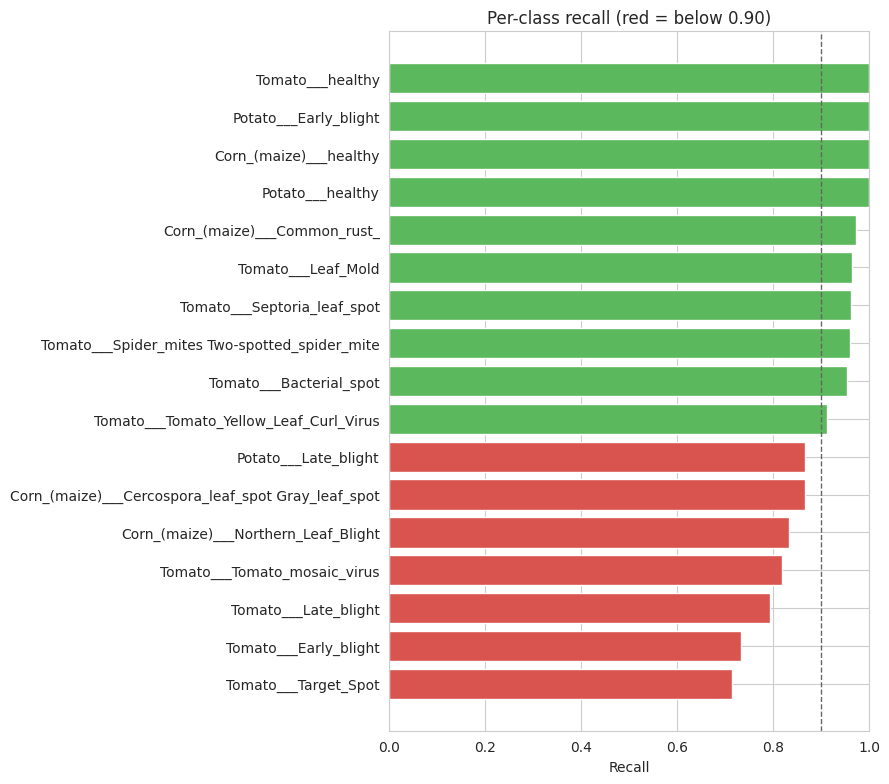


Top confused pairs:


,true,predicted_as,count,rate
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Spider_mites Two-spotted_spider_mite,12,0.074534
1,Tomato___Target_Spot,Tomato___healthy,9,0.214286
2,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,5,0.166667
3,Tomato___Late_blight,Potato___Late_blight,4,0.068966
4,Tomato___Target_Spot,Tomato___Spider_mites Two-spotted_spider_mite,3,0.071429
5,Tomato___Early_blight,Tomato___healthy,2,0.066667
6,Potato___Late_blight,Potato___healthy,2,0.066667
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,2,0.133333


In [ ]:
# Per-class recall, worst first
recall_per_class = cm.diagonal() / cm.sum(axis=1)
weak = (pd.DataFrame({"class": CLASS_NAMES, "recall": recall_per_class,
                      "test_images": cm.sum(axis=1)})
        .sort_values("recall"))

fig, ax = plt.subplots(figsize=(9, 0.35 * NUM_CLASSES + 2))
colors = ["#d9534f" if r < 0.9 else "#5cb85c" for r in weak["recall"]]
ax.barh(weak["class"], weak["recall"], color=colors)
ax.axvline(0.9, ls="--", color="#666", lw=1)
ax.set_xlim(0, 1)
ax.set_xlabel("Recall")
ax.set_title("Per-class recall (red = below 0.90)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_recall.png", dpi=150)
plt.show()

# Most-confused class pairs
pairs = [(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j]), cm[i, j] / cm[i].sum())
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
         if i != j and cm[i, j] > 0]
confusions = (pd.DataFrame(pairs, columns=["true", "predicted_as", "count", "rate"])
              .sort_values("count", ascending=False).head(8).reset_index(drop=True))
print("\nTop confused pairs:")
confusions

### 9.5 Error analysis — looking at the actual failures

Counting mistakes is not error analysis; looking at them is. The grid below shows the
model's most *confident* wrong answers, which are the dangerous ones — a low-confidence
error gets caught by the app's "consult an extension worker" warning, whereas a
95%-confident wrong answer does not.

In [ ]:
test_paths = test_df["filepath"].values
wrong = np.where(best_pred != y_true)[0]
print(f"{len(wrong)} misclassified out of {len(y_true)} test images "
      f"({100*len(wrong)/len(y_true):.2f}%)")

if len(wrong):
    conf = best_probs[wrong].max(axis=1)
    worst = wrong[np.argsort(-conf)][:8]          # confidently wrong

    fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
    for ax, idx in zip(axes.ravel(), worst):
        ax.imshow(Image.open(test_paths[idx]).resize((200, 200)))
        ax.axis("off")
        ax.set_title(
            f"True: {CLASS_NAMES[y_true[idx]].split('___')[-1][:22]}\n"
            f"Pred: {CLASS_NAMES[best_pred[idx]].split('___')[-1][:22]}\n"
            f"({best_probs[idx].max():.0%} confident)",
            fontsize=8, color="#b00")
    for ax in axes.ravel()[len(worst):]:
        ax.axis("off")
    plt.suptitle("Most confidently wrong predictions", y=1.0)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "error_analysis_failures.png", dpi=140)
    plt.show()
else:
    print("No misclassifications — check for data leakage before celebrating.")

### 9.6 Confidence calibration — is low confidence a useful warning signal?

The demo app tells the user to consult an extension worker when confidence is low. That
advice is only worth giving if confidence actually correlates with correctness. This cell
tests that assumption instead of assuming it.

        images  accuracy
bucket                  
<50%        17     0.529
50-70%      60     0.633
70-85%      58     0.776
85-95%      73     0.822
>95%       518     0.977


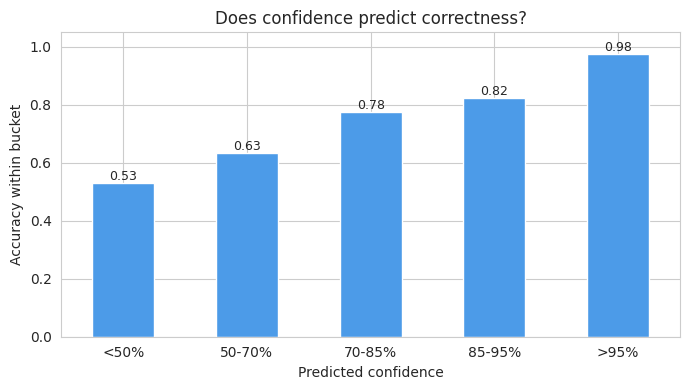

In [ ]:
conf_all = best_probs.max(axis=1)
correct = (best_pred == y_true)

bins = [0, 0.5, 0.7, 0.85, 0.95, 1.0001]
buckets = pd.cut(conf_all, bins, right=False,
                 labels=["<50%", "50-70%", "70-85%", "85-95%", ">95%"])
calib = pd.DataFrame({"bucket": buckets, "correct": correct})
summary = calib.groupby("bucket", observed=False).agg(
    images=("correct", "size"), accuracy=("correct", "mean"))
print(summary.round(3))

ax = summary["accuracy"].plot(kind="bar", figsize=(7, 4), rot=0, color="#4c9be8",
                              ylim=(0, 1.05))
ax.bar_label(ax.containers[0], fmt="%.2f", fontsize=9)
ax.set_ylabel("Accuracy within bucket")
ax.set_xlabel("Predicted confidence")
ax.set_title("Does confidence predict correctness?")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confidence_calibration.png", dpi=150)
plt.show()

## 10. Ablation Study *(optional — set `RUN_ABLATION = True`)*

The brief asks us to show that our optimisation/regularisation choices actually earned
their place. Each variant below trains the same transfer-learning head with **one thing
removed**, for a fixed small number of epochs so the comparison is fair. Only stage 1 is
run (frozen backbone), which keeps this to a few minutes while still isolating the effect
of each design choice.

In [ ]:
ABLATION_EPOCHS = 3

def run_ablation():
    variants = {
        "Full setup":            dict(augment=True,  dropout=0.3, weighted=True),
        "No augmentation":       dict(augment=False, dropout=0.3, weighted=True),
        "No dropout":            dict(augment=True,  dropout=0.0, weighted=True),
        "No class weights":      dict(augment=True,  dropout=0.3, weighted=False),
    }
    rows = []
    for name, cfg in variants.items():
        print(f"\n=== {name} ===")
        tf.random.set_seed(SEED)      # NOT clear_session(): that would invalidate
                                      # train_ds/val_ds/test_ds and y_true above

        base = BackboneFn(include_top=False, weights="imagenet",
                          input_shape=(*IMG_SIZE, 3))
        base.trainable = False

        # fresh augmentation stack per variant so runs stay independent
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal_and_vertical", seed=SEED),
            layers.RandomRotation(0.15, seed=SEED),
            layers.RandomZoom(0.15, seed=SEED),
            layers.RandomTranslation(0.10, 0.10, seed=SEED),
            layers.RandomContrast(0.15, seed=SEED),
        ])

        inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
        x = aug(inputs) if cfg["augment"] else inputs
        x = preprocess_input(x)
        x = base(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        if cfg["dropout"] > 0:
            x = layers.Dropout(cfg["dropout"])(x)
        out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

        m = tf.keras.Model(inputs, out)
        m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        m.fit(train_ds, validation_data=val_ds, epochs=ABLATION_EPOCHS,
              class_weight=class_weight if cfg["weighted"] else None, verbose=2)

        pred = m.predict(test_ds, verbose=0).argmax(axis=1)
        _, _, f1, _ = precision_recall_fscore_support(y_true, pred, average="macro",
                                                      zero_division=0)
        rows.append({"variant": name, "test_accuracy": accuracy_score(y_true, pred),
                     "test_macro_f1": f1})
        del m, base                      # free GPU memory before the next variant

    out = pd.DataFrame(rows)
    out["delta_macro_f1"] = out["test_macro_f1"] - out.loc[0, "test_macro_f1"]
    return out


if RUN_ABLATION:
    ablation = run_ablation()
    ablation.to_csv(RESULTS_DIR / "ablation_study.csv", index=False)
    display(ablation.round(4))
else:
    print("RUN_ABLATION is False — skipped. Set it to True in the config cell "
          f"to run the {ABLATION_EPOCHS}-epoch ablation.")

## 11. Save Artifacts for the Repo & Demo App

Everything the rest of the team needs. Note the **`class_names.json`** file: hard-coding
the class list in the app and hoping it matches the training order is the single most
common way a working model produces nonsense predictions in a demo. The app should read
this file instead.

In [ ]:
# --- Models --------------------------------------------------------
transfer_model.save(str(MODEL_DIR / "crop_disease_model.keras"))  # the one the app ships
cnn_model.save(str(MODEL_DIR / "baseline_cnn.keras"))             # kept for comparison

# --- Class order (authoritative) ------------------------------------
with open(MODEL_DIR / "class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

# --- Regularisation/optimisation register for the report -------------
techniques = pd.DataFrame([
    ("Data augmentation",   "flip / rotate / zoom / shift / contrast", "both models"),
    ("Dropout",             "0.4 (CNN head), 0.3 (transfer head)",     "both models"),
    ("Batch normalisation", "after every conv block",                  "baseline CNN"),
    ("L2 weight decay",     "1e-4 on conv + dense kernels",            "baseline CNN"),
    ("Early stopping",      "val_loss, restore best weights",          "both models"),
    ("LR scheduling",       "ReduceLROnPlateau, factor 0.5",           "both models"),
    ("Class weighting",     "balanced, from training split",           "both models"),
    ("Transfer learning",   f"{BACKBONE} + 2-stage fine-tuning",       "model 2"),
], columns=["technique", "setting", "applied to"])
techniques.to_csv(RESULTS_DIR / "regularisation_techniques.csv", index=False)

print("Saved to", MODEL_DIR)
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name:35s} {p.stat().st_size/1e6:8.1f} MB")
print("\nSaved to", RESULTS_DIR)
for p in sorted(RESULTS_DIR.iterdir()):
    print("  ", p.name)

print("\n" + "=" * 68)
print("CONTRACT FOR app.py  (preprocessing is baked into the model)")
print("=" * 68)
print("  1. Copy crop_disease_model.keras -> <repo>/model/crop_disease_model.keras")
print("  2. Copy class_names.json          -> <repo>/model/class_names.json")
print("  3. In app.py, feed the model a RAW [0,255] image — do NOT divide by 255:")
print("         img = image.convert('RGB').resize((224, 224))")
print("         x   = np.expand_dims(np.array(img, dtype='float32'), 0)")
print("         probs = model.predict(x)[0]")
print("  4. Load CLASS_NAMES from class_names.json rather than hard-coding it.")
print("=" * 68)
techniques

## 12. Demo Interface

A Jupyter-based interactive demo, which the brief accepts as the demo interface for
Task 3 (the Streamlit app in the repo is the polished version for the live presentation).
It takes an image path or an upload and returns a farmer-readable diagnosis, a confidence
band, and a suggested next step.

The low-confidence warning is deliberate: for a tool aimed at smallholder farmers, a
confidently wrong answer that triggers unnecessary pesticide spending is worse than an
honest "I'm not sure — check with your extension worker".

In [ ]:
TREATMENT_ADVICE = {
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot":
        "Rotate crops and avoid late-day overhead irrigation; consider a fungicide if lesions spread fast.",
    "Corn_(maize)___Common_rust_":
        "Usually manageable — monitor spread. Fungicide rarely needed unless severe and early in the season.",
    "Corn_(maize)___Northern_Leaf_Blight":
        "Rotate crops next season and remove infected residue after harvest. Early fungicide may help.",
    "Corn_(maize)___healthy": "No action needed. Keep monitoring weekly.",
    "Potato___Early_blight":
        "Remove affected leaves, rotate crops, avoid late-day overhead irrigation.",
    "Potato___Late_blight":
        "Act quickly — this can destroy a crop within days in wet weather. Contact your agriculture service centre.",
    "Potato___healthy": "No action needed. Keep monitoring weekly.",
    "Tomato___Bacterial_spot":
        "Remove infected leaves, avoid working in wet fields, disinfect tools between plants.",
    "Tomato___Early_blight":
        "Remove lower infected leaves, improve airflow between plants, avoid overhead watering.",
    "Tomato___Late_blight":
        "Act quickly — spreads fast in humid weather. Remove infected plants and contact your agriculture service centre.",
    "Tomato___Leaf_Mold":
        "Improve ventilation and spacing; reduce humidity around the foliage where possible.",
    "Tomato___Septoria_leaf_spot":
        "Remove lower infected leaves promptly and avoid wetting foliage when watering.",
    "Tomato___Spider_mites Two-spotted_spider_mite":
        "Rinse leaves with water to dislodge mites; monitor closely in hot, dry weather.",
    "Tomato___Target_Spot":
        "Remove infected leaves and improve airflow; avoid overhead watering.",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus":
        "Spread by whiteflies — control whiteflies and remove severely infected plants.",
    "Tomato___Tomato_mosaic_virus":
        "Remove and destroy infected plants; wash hands and tools afterwards.",
    "Tomato___healthy": "No action needed. Keep monitoring weekly.",
}


def display_name(class_name):
    crop, _, disease = class_name.partition("___")
    crop = crop.replace("_", " ").replace("(maize)", "(Maize)").strip()
    disease = disease.replace("_", " ").strip()
    return f"{crop} — Healthy" if disease.lower() == "healthy" else f"{crop} — {disease}"


def diagnose(image_or_path, model=None, show=True, top_k=3):
    model = model or best_model
    img = (Image.open(image_or_path) if isinstance(image_or_path, (str, Path))
           else image_or_path).convert("RGB")

    x = np.expand_dims(np.array(img.resize(IMG_SIZE), dtype="float32"), 0)
    probs = model.predict(x, verbose=0)[0]
    order = probs.argsort()[::-1][:top_k]
    top, conf = CLASS_NAMES[order[0]], float(probs[order[0]])

    if show:
        plt.figure(figsize=(3.2, 3.2))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        band = ("HIGH confidence" if conf >= 0.75 else
                "MODERATE confidence" if conf >= 0.45 else
                "LOW confidence — please double-check with an extension worker")
        print(f"Diagnosis : {display_name(top)}")
        print(f"Confidence: {conf:.1%}  [{band}]")
        print(f"Next step : {TREATMENT_ADVICE.get(top, 'No advice recorded for this class.')}")
        print("\nOther possibilities:")
        for i in order[1:]:
            print(f"   {display_name(CLASS_NAMES[i]):45s} {probs[i]:6.1%}")
        if conf < 0.45:
            print("\n  This tool is decision support, not a diagnosis. Confirm with your "
                  "nearest agriculture service centre before spending money on treatment.")
        print("-" * 70)

    return top, conf, probs


# Demo on a few random test images the model has never seen
for path in test_df["filepath"].sample(3, random_state=SEED):
    diagnose(path)

In [ ]:
# --- Optional: upload your own photo -------------------------------
# Colab:
#     from google.colab import files
#     up = files.upload()
#     for fname in up:
#         diagnose(fname)
#
# Jupyter / Kaggle (needs ipywidgets):
#     import ipywidgets as widgets
#     from IPython.display import display as ipy_display
#     uploader = widgets.FileUpload(accept="image/*", multiple=False)
#     ipy_display(uploader)
#     # after uploading, run:
#     # diagnose(Image.open(io.BytesIO(list(uploader.value)[0]["content"])))
print("See the comments in this cell to try the model on your own leaf photo.")

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create File Upload widget
upload_btn = widgets.FileUpload(
    accept='image/*',   # accept any image format (.jpg, .png, etc.)
    multiple=False,     # single image at a time
    description='Upload Leaf Photo',
    button_style='success',
    icon='upload',
    layout=widgets.Layout(width='240px', height='40px')
)

output_area = widgets.Output()

def handle_upload(change):
    # Retrieve uploaded file
    uploaded_file = upload_btn.value
    if not uploaded_file:
        return

    with output_area:
        clear_output(wait=True)
        try:
            # Handle both ipywidgets v7 and v8 structure
            if isinstance(uploaded_file, tuple):
                content = uploaded_file[0]['content']
            else:
                file_name = list(uploaded_file.keys())[0]
                content = uploaded_file[file_name]['content']

            # Convert binary bytes stream to PIL Image
            uploaded_image = Image.open(io.BytesIO(content))

            # Run inference pipeline
            diagnose(uploaded_image)

        except Exception as e:
            print(f"Error processing image: {e}")

# Observe changes on the upload widget
upload_btn.observe(handle_upload, names='value')

# Render in notebook
print("Upload your own crop leaf photo to test the model:\n")
display(upload_btn)
display(output_area)

Upload your own crop leaf photo to test the model:



FileUpload(value={}, accept='image/*', button_style='success', description='Upload Leaf Photo', layout=Layout(…

Output()